Problems:
    - after a while, returns explode and oscilate between -7.5 and +7.5 until end of sample
    - when lambda is to low, one extreme beta estimate destabilizes the whole system and this extreme estimate carries over to future periods
    - when lambda is to high, all coefficients are penalized away
    - if the simulation does not explode, there is a timing issue, coefficients estimated in simulation and empirical are off by 1 day

What remains to do:

    - think about whether this makes sense
    - code a loop that tests a range of standard deviations and stores them along with n_active and r2

Fixed so far:

    - centered returns as in the empirical function
    - scaled topic matrix before LASSO and scaled back before giving to ALM


In [2]:
import os

os.getcwd()
os.chdir(r'C:\Users\jonat\Lasso_paper\Empirical\estimation')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from scipy.optimize import curve_fit
from scipy.stats.mstats import winsorize

import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# Importing from your provided scripts
from stage1 import to_ar1_innovations, create_lagged_features
from grid_search import estimate_single_config_fast

In [3]:
# Parameter calibration
a = 1.001 # mean of the dividend process
gamma = 2.0 # risk aversion
sigma = 0.00006 # std dev of the dividend process
delta = 0.96 # discount factor
phi = np.exp(sigma**2 / 2) # correction term for lognormality
kappa = delta * a ** ( - gamma) * phi
w = - np.log(kappa) - np.exp(-10)  # small constant to ensure positivity
print(f"w: {w}, kappa: {kappa}")

import statsmodels.api as sm

topics = pd.read_csv(r"C:\Users\jonat\Lasso_paper\Empirical\data\merged_return_topic_data.csv")
topics = topics[[col for col in topics.columns if not any(char.isdigit() for char in col)]]
topics.set_index('date', inplace=True)
topics = to_ar1_innovations(topics)
topics = topics.iloc[1:]

w: 0.042775593456659704, kappa: 0.9580828778893434


NameError: name 'sm' is not defined

In [123]:
def multivariate_CGL_offline_lasso(X, sigma, kappa, w, rolling_window_size=252, lambda_lasso=0.01, correct_with_tanh=True, random_number=42, standardize=True, n_lags=1):
    
    T, K = X.shape
    X = np.asarray(X)
    assert rolling_window_size < T, "rolling_window_size must be less than T"

    # Generate Lagged Features 
    X_padded = np.vstack([X, np.zeros((1, K))])
    X_lagged, _ = create_lagged_features(X_padded, n_lags)
    n_features = X_lagged.shape[1]

    # Ensure beta array can hold the number of features
    beta_offline = np.zeros((T, n_features, 1))
    intercept_offline = np.zeros(T)
    r_offline = np.zeros(T)
    n_active = 0  
    predictions = np.zeros(T)
    np.random.seed(random_number)

    # Adjust burn-in phase to account for n_lags
    r_offline[1:rolling_window_size + n_lags] = np.random.normal(0, sigma, rolling_window_size + n_lags - 1)

    # Initialize model outside loop for actual warm_start performance
    model = Lasso(alpha=lambda_lasso, fit_intercept=False, random_state=42, warm_start=True, tol = 1e-3)

    # Start the loop after the burn-in and lag offset
    for t in range(rolling_window_size + n_lags, T):
        
        # Extract the rolling window directly from the lagged feature matrix
        x_current = X_lagged[t - rolling_window_size - n_lags : t - n_lags, :] 
        r_offline_current = r_offline[t - rolling_window_size : t] 
        r_centered = r_offline_current - np.mean(r_offline_current)

        if standardize:
            scaler = StandardScaler()
            x_current = scaler.fit_transform(x_current)
        else:
            scaler = None
            x_current = x_current

        model.fit(x_current, r_centered)
        
        # Calculate rescaled coefficients and the implied intercept
        if standardize:
            coef = model.coef_ / scaler.scale_
            intercept = -np.dot(scaler.mean_, coef) 
        else:
            coef = model.coef_
            intercept = 0

        beta_offline[t-1] = coef.reshape(-1, 1)
        intercept_offline[t-1] = intercept
        n_active += np.count_nonzero(beta_offline[t-1])

        x_t_lagged = X_lagged[t + 1 - n_lags, :].reshape(1, -1)
        
        if standardize:
            predictions[t] = model.predict(scaler.transform(x_t_lagged))[0] 
        else:
            predictions[t] = model.predict(x_t_lagged)[0] 

        pred_t_minus_1 = predictions[t-1]
        pred_t_minus_2 = predictions[t-2]

        if correct_with_tanh:
            r_offline[t] = (np.log(1 - kappa * np.exp(w * np.tanh(pred_t_minus_2 / w))) - 
                            np.log(1 - kappa * np.exp(w * np.tanh(pred_t_minus_1 / w))) + 
                            np.random.normal(0, sigma)).item()
        else:
            r_offline[t] = (np.log(1 - kappa * np.exp(pred_t_minus_2)) - 
                            np.log(1 - kappa * np.exp(pred_t_minus_1)) + 
                            np.random.normal(0, sigma)).item() 
    
    return beta_offline, r_offline, n_active, predictions

In [124]:
def estimate_kappa_nls(predictions, r_offline, w, correct_with_tanh=True, rolling_window_size=20, n_lags=1):
    """
    Estimates the parameter kappa and intercept using curve_fit, 
    using the EXACT predictions array generated during the simulation.
    """
    # Start at the same point the simulation loop started
    start_t = rolling_window_size + n_lags

    # 1. Align the timing EXACTLY as it was in the simulation
    # In simulation: r_offline[t] was generated using predictions[t-2] and predictions[t-1]
    r = r_offline[start_t:]
    
    # Extract the exact corresponding prediction arrays
    pred_t_minus_2 = predictions[start_t - 2 : len(predictions) - 2]
    pred_t_minus_1 = predictions[start_t - 1 : len(predictions) - 1]
    
    # 2. Apply tanh correction if required
    if correct_with_tanh:
        p_t2_input = w * np.tanh(pred_t_minus_2 / w)
        p_t1_input = w * np.tanh(pred_t_minus_1 / w)
    else:
        p_t2_input = pred_t_minus_2
        p_t1_input = pred_t_minus_1
        
    # 3. Define the ALM model exactly as it appears in the simulation's return calculation
    def alm_model(x, kappa, intercept):
        pt2, pt1 = x
        
        # Replicate the exact safety net from the simulation
        term1 = np.maximum(1e-5, 1 - kappa * np.exp(pt2))
        term2 = np.maximum(1e-5, 1 - kappa * np.exp(pt1))
        
        return np.log(term1) - np.log(term2) + intercept

    # 4. Prevent invalid logs by dynamically bounding kappa's upper limit
    max_exp = max(np.max(np.exp(p_t2_input)), np.max(np.exp(p_t1_input)))
    kappa_upper_bound = min(1.0, 0.9999 / max_exp)
    
    try:
        popt, _ = curve_fit(
            alm_model, 
            (p_t2_input, p_t1_input), 
            r,
            p0=[0.5, 0.0],
            bounds=([0.0, -1.0], [kappa_upper_bound, 1.0])
        )
        
        kappa_est, intercept_est = popt
        
        # Compute R-squared on the valid time window
        r_pred_final = alm_model((p_t2_input, p_t1_input), kappa_est, intercept_est)
        r2 = r2_score(r, r_pred_final)
        
        return kappa_est, intercept_est, r2
        
    except Exception as e:
        print(f"Curve fit failed: {e}")
        return np.nan, np.nan, np.nan

Number active 31
Penalty 0.00239
True Kappa: 0.9581307815062262, Estimated Kappa: 0.9581651245769217


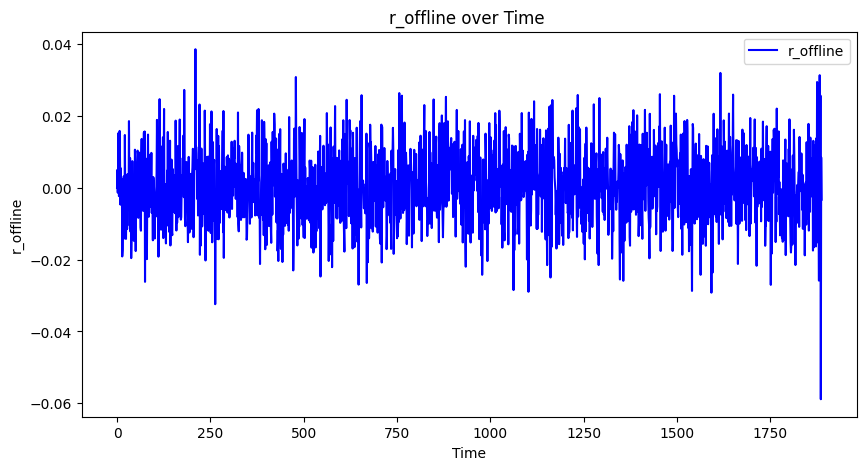

In [125]:
lambda_lasso = 0.00239
beta_offline, r_offline, n_active, predictions = multivariate_CGL_offline_lasso(topics, 
                                                                   sigma, 
                                                                   kappa, 
                                                                   w, 
                                                                   rolling_window_size = 252, 
                                                                   lambda_lasso = lambda_lasso, 
                                                                   correct_with_tanh=True, 
                                                                   random_number=42,
                                                                   standardize=True)
print(f"Number active {n_active}")
print(f"Penalty {lambda_lasso}")
kappa_est, int_est, r2 = estimate_kappa_nls(predictions, r_offline, w=w, correct_with_tanh=True)

print(f"True Kappa: {kappa}, Estimated Kappa: {kappa_est}")

plt.figure(figsize=(10, 5))
plt.plot(r_offline, label='r_offline', color='blue')
plt.title('r_offline over Time ')
plt.xlabel('Time')
plt.ylabel('r_offline')
plt.legend()
plt.show()

In [126]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# 0. Identify topic names (assuming 'topics' is a DataFrame)
topic_names = topics.columns.tolist()
warnings.filterwarnings("ignore", category=ConvergenceWarning)
results_list = []

# Loop through random states
for seed in range(50):
    if seed % 1 == 0:
        print(f"Processing random_state {seed} out of 25...")
        
    # 1. Run the offline Lasso model
    beta_offline, r_offline, n_active, predictions = multivariate_CGL_offline_lasso(topics, sigma, kappa, w, rolling_window_size = 252, lambda_lasso =  lambda_lasso, correct_with_tanh=True, random_number=seed)

    
    # Clean the beta matrix (handle nesting/singleton dimensions)
    beta_cleaned = np.squeeze(beta_offline)
    
    # 2. Convert the beta matrix into a named DataFrame
    beta_named_df = pd.DataFrame(beta_cleaned, columns=topic_names)
    
    # 3. Estimate the ALM parameters via NLS
    kappa_est, int_est, r2 = estimate_kappa_nls(predictions, r_offline, w=w, correct_with_tanh=True)

    
    # 4. Append the results
    results_list.append({
        'random_state': seed,
        'n_active_total': n_active,
        'kappa_est': kappa_est,
        'intercept_est': int_est,
        'r2_score': r2,
        # Now storing a named DataFrame instead of a raw array
        'beta_coefficients': beta_named_df, 
        'r_offline': r_offline.copy() 
    })

# 5. Convert to main results DataFrame
results_df = pd.DataFrame(results_list)

print("\nSimulation Complete!")

Processing random_state 0 out of 25...
Processing random_state 1 out of 25...
Processing random_state 2 out of 25...
Processing random_state 3 out of 25...
Processing random_state 4 out of 25...
Processing random_state 5 out of 25...
Processing random_state 6 out of 25...
Processing random_state 7 out of 25...
Processing random_state 8 out of 25...
Processing random_state 9 out of 25...
Processing random_state 10 out of 25...
Processing random_state 11 out of 25...
Processing random_state 12 out of 25...
Processing random_state 13 out of 25...
Processing random_state 14 out of 25...
Processing random_state 15 out of 25...
Processing random_state 16 out of 25...
Processing random_state 17 out of 25...
Processing random_state 18 out of 25...
Processing random_state 19 out of 25...
Processing random_state 20 out of 25...
Processing random_state 21 out of 25...
Processing random_state 22 out of 25...
Processing random_state 23 out of 25...
Processing random_state 24 out of 25...
Processing

In [127]:
# Get Topic 1 (e.g., 'Natural disasters') from the first run
first_run_betas = results_df['beta_coefficients'].iloc[0]
natural_disasters_series = first_run_betas['Natural disasters']
print(f"Mean Beta for Natural disasters in Run 0: {natural_disasters_series.mean():.6f}")

Mean Beta for Natural disasters in Run 0: 0.000000


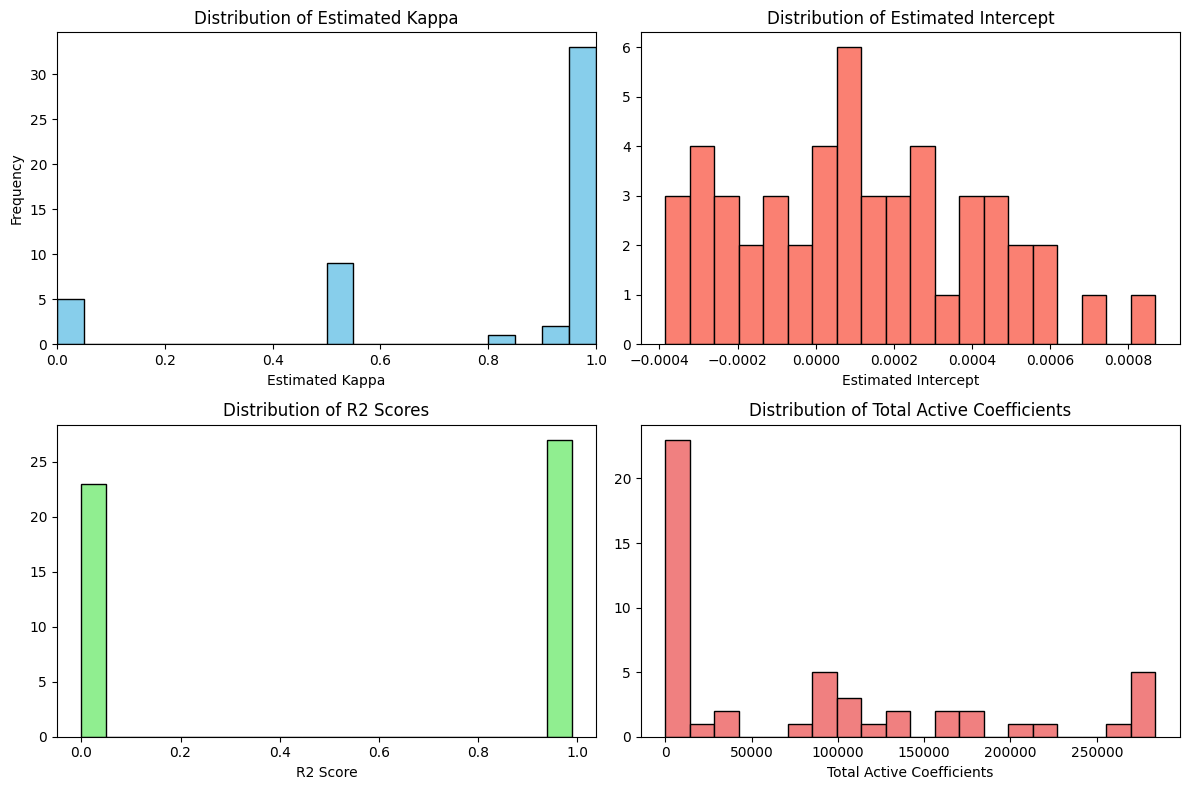

In [128]:
# plot the results
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.hist(results_df['kappa_est'].dropna(), bins=20, range=(0, 1), color='skyblue', edgecolor='black')
plt.title('Distribution of Estimated Kappa')
plt.xlabel('Estimated Kappa')
plt.ylabel('Frequency')
# Set the x-axis limits strictly from 0 to 1
plt.xlim(0, 1)
plt.subplot(2, 2, 2)
plt.hist(results_df['intercept_est'].dropna(), bins=20, color='salmon', edgecolor='black')
plt.title('Distribution of Estimated Intercept')
plt.xlabel('Estimated Intercept')
plt.subplot(2, 2, 3)
plt.hist(results_df['r2_score'].dropna(), bins=20, color='lightgreen', edgecolor='black')
plt.title('Distribution of R2 Scores')
plt.xlabel('R2 Score')
plt.subplot(2, 2, 4)
plt.hist(results_df['n_active_total'], bins=20, color='lightcoral', edgecolor='black')
plt.title('Distribution of Total Active Coefficients')
plt.xlabel('Total Active Coefficients')
plt.tight_layout()
plt.show()


In [129]:
import numpy as np
import pandas as pd

# 1. Convert the list of beta matrices into a 3D NumPy array
# Shape: (n_seeds, n_time_steps, n_topics)
beta_stack = np.array(results_df['beta_coefficients'].tolist())

# Clean up singleton dimensions if the Lasso output had a shape like (T, K, 1)
if beta_stack.ndim > 3:
    beta_stack = beta_stack.squeeze()

# 2. Calculate the count of non-zero occurrences across seeds
# We sum the boolean (beta != 0) along axis 0 (the random seeds axis)
selection_counts = (beta_stack != 0).sum(axis=0)

# 3. Organize into a DataFrame for easy inspection
# Rows = Time Steps, Columns = Topics
selection_counts_df = pd.DataFrame(
    selection_counts, 
    columns=[f'Topic_{i}' for i in range(selection_counts.shape[1])]
)

# 4. Optional: Add a 'Time_Step' index or column if you have dates
selection_counts_df.index.name = 'Time_Step'

# Display the result


# To see the total selection count across all time and all seeds for each topic:
print("\nTotal 'Active' instances across the entire period per topic:")
print(selection_counts_df.sum())

# out of all cells that are not 0, count the cells that are equal to 10
print("\nCount of cells that are exactly 10 (selected in all runs):")
print((selection_counts_df == 10).sum().sum())


Total 'Active' instances across the entire period per topic:
Topic_0      22775
Topic_1      22802
Topic_2      22809
Topic_3      22781
Topic_4      22728
             ...  
Topic_175    22840
Topic_176    22831
Topic_177    22802
Topic_178    22839
Topic_179    22882
Length: 180, dtype: int64

Count of cells that are exactly 10 (selected in all runs):
12217


C:\Users\jonat\AppData\Local\Temp\ipykernel_25880\3998749825.py:16: RuntimeWarning: Mean of empty slice
  mean_beta_active = np.nanmean(beta_temp, axis=0)
c:\Users\jonat\anaconda3\envs\reddit_env\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


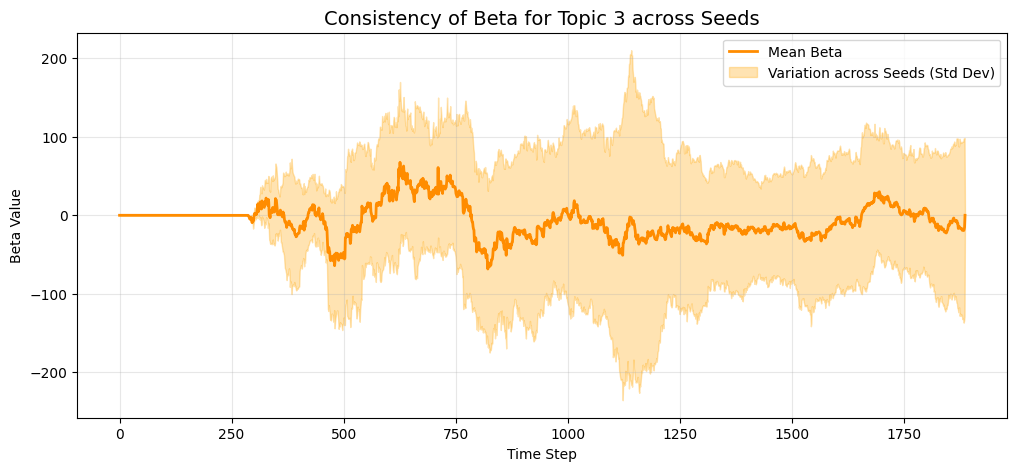

Max variation (Std Dev) for Topic 3: 213.360349


In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare and Squeeze the stack
beta_stack = np.array(results_df['beta_coefficients'].tolist())
# This removes any singleton dimensions (like the '1' in (20, T, K, 1))
beta_stack = np.squeeze(beta_stack)

# 2. Identify where topics were selected
# Replace zeros with NaN so they don't bias the Mean/Std Dev
beta_temp = beta_stack.copy().astype(float)
beta_temp[beta_temp == 0] = np.nan

# 3. Calculate Mean and Std across seeds (axis 0)
mean_beta_active = np.nanmean(beta_temp, axis=0)
std_beta_active = np.nanstd(beta_temp, axis=0)

# 4. Plotting for Topic 1
topic_idx = 3

# Extract the 1D arrays for the specific topic
# We use .flatten() just in case there are hidden dimensions
x = np.arange(mean_beta_active.shape[0])
y_mean = mean_beta_active[:, topic_idx].flatten()
y_std = std_beta_active[:, topic_idx].flatten()

# Fill NaNs with 0 for the plot so it doesn't break the line
y_mean_plot = np.nan_to_num(y_mean)
y_std_plot = np.nan_to_num(y_std)

plt.figure(figsize=(12, 5))

# Plot the mean line
# Gives the mean across seeds for the topic's coefficient at each time step
plt.plot(x, y_mean_plot, color='darkorange', lw=2, label='Mean Beta')

# Plot the variation band (Std Dev)
# A wide orange band means that the coefficient is inconsistent across runs, while a narrow band means it's consistent
plt.fill_between(
    x, 
    y_mean_plot - y_std_plot, 
    y_mean_plot + y_std_plot, 
    alpha=0.3, 
    color='orange', 
    label='Variation across Seeds (Std Dev)'
)

plt.title(f'Consistency of Beta for Topic {topic_idx} across Seeds', fontsize=14)
plt.ylabel('Beta Value')
plt.xlabel('Time Step')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# If all estimations were the same, this would be 0, meaning no variation across seeds
print(f"Max variation (Std Dev) for Topic {topic_idx}: {np.nanmax(y_std):.6f}")

In [131]:
# 1. Calculate the global stats for each topic across all time steps
# We take the mean of the Std Devs over time to see general stability
avg_std_per_topic = np.nanmean(std_beta_active, axis=0) 
max_std_per_topic = np.nanmax(std_beta_active, axis=0)
avg_beta_per_topic = np.nanmean(mean_beta_active, axis=0)

# 2. Create a DataFrame for all 180 topics
topics_range = np.arange(1, 181)
summary_stats = pd.DataFrame({
    'Topic': topics_range,
    'Avg Beta (Signal)': avg_beta_per_topic,
    'Avg Std Dev (Noise)': avg_std_per_topic,
    'Max Std Dev': max_std_per_topic
})

# 3. Add the Coefficient of Variation (CV) 
# High CV (> 1.0) means the noise is stronger than the signal
summary_stats['Stability (CV)'] = summary_stats['Avg Std Dev (Noise)'] / np.abs(summary_stats['Avg Beta (Signal)'])

# 4. Display the table (showing top 20 or the whole thing)
print("--- Topic Stability Summary (Topics 1-180) ---")
print(summary_stats.to_string(index=False, max_rows=180))

# Optional: Find the "Troublemakers" (Topics with Std Dev > 0.5)
troublemakers = summary_stats[summary_stats['Max Std Dev'] > 0.5]
print(f"\nFound {len(troublemakers)} topics with high volatility (Max SD > 0.5).")

--- Topic Stability Summary (Topics 1-180) ---
 Topic  Avg Beta (Signal)  Avg Std Dev (Noise)  Max Std Dev  Stability (CV)
     1           4.447351           131.781325   225.948197       29.631422
     2          11.973376            97.228723   154.761138        8.120410
     3          11.053647           210.805429   358.718513       19.071120
     4          -8.165113            89.913124   213.360349       11.011866
     5         -45.018548           239.003167   409.364600        5.308993
     6         -19.005799           269.192875   495.070484       14.163723
     7         -67.876134           359.614039   666.532329        5.298093
     8          -3.440162           104.333124   229.340738       30.327968
     9         -64.888311           249.435222   474.213749        3.844070
    10         -11.878974           196.617250   345.529375       16.551703
    11         -57.631389           335.595293   631.628210        5.823134
    12         -88.193156           342.8

After simulating data, we feed the same data into our empirircal code.

------------------------------
RESULTS FOR RUN 0 (Random State: 1)
------------------------------
R² Score:          0.988950
Kappa (Estimated): 0.958078
Intercept:         0.000428
Total Active:      182833


Text(0.5, 1.0, 'r_offline over Time for Run 0')

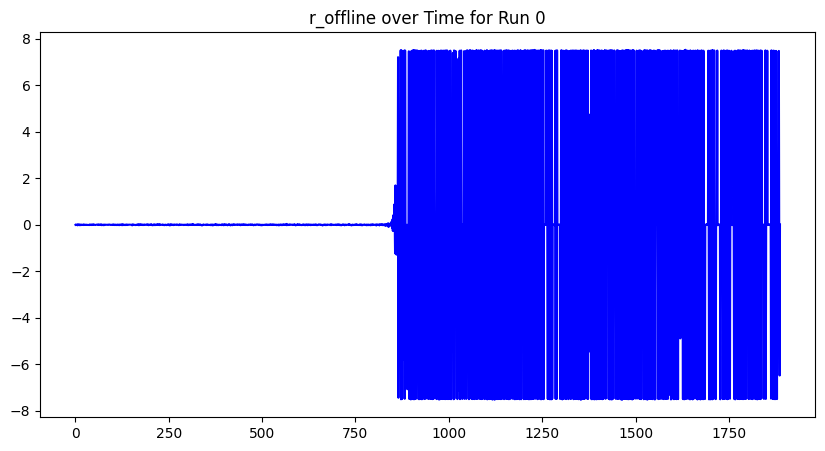

In [132]:
# 1. Extract the first row as a Series
first_run = results_df.iloc[1]
r_offline_0 = first_run['r_offline']


# 2. Print scalar metrics and parameters
print("-" * 30)
print(f"RESULTS FOR RUN 0 (Random State: {first_run['random_state']})")
print("-" * 30)
print(f"R² Score:          {first_run['r2_score']:.6f}")
print(f"Kappa (Estimated): {first_run['kappa_est']:.6f}")
print(f"Intercept:         {first_run['intercept_est']:.6f}")
print(f"Total Active:      {first_run['n_active_total']}")

# plot r_offline for the first run
plt.figure(figsize=(10, 5))
plt.plot(r_offline_0, label='r_offline (Run 0)', color='blue')
plt.title('r_offline over Time for Run 0')

In [133]:
results = estimate_single_config_fast(topics, r_offline_0, window_size = 252, n_lags = 1, lambda_val = lambda_lasso, standardize=True, verbose=False, save_only_positve_r_squared = False, return_details=True)

C:\Users\jonat\Lasso_paper\Empirical\estimation\stage2.py:25: RuntimeWarning: invalid value encountered in log
  return np.log(1 - kappa * np.exp(pred_t)) - np.log(1 - kappa * np.exp(pred_t1)) + intercept


In [134]:
# get betas from empirical run
beta_columns = [col for col in results['details'].columns if col.startswith('Lasso_')]
betas_empirical = results['details'][beta_columns].values
betas_empirical = np.squeeze(betas_empirical)

In [135]:
# 1. Extract the simulated betas from Run 0
# We use .iloc[0] and convert to NumPy to match the empirical data type
sim_betas_raw = results_df['beta_coefficients'].iloc[0].values 

# 2. Align Lengths (Trimming the simulated betas to match the empirical length)
# Assuming the empirical betas start after the first rolling window
if sim_betas_raw.shape[0] > betas_empirical.shape[0]:
    # Calculate the offset (should be 20)
    offset = sim_betas_raw.shape[0] - betas_empirical.shape[0]
    sim_betas_aligned = sim_betas_raw[offset:, :]
else:
    sim_betas_aligned = sim_betas_raw

# 3. Final Conversion and Shape Squeeze
# This ensures both are <class 'numpy.ndarray'> with shape (1868, 180)
sim_betas_final = np.ascontiguousarray(sim_betas_aligned)
emp_betas_final = np.ascontiguousarray(betas_empirical)

total_corr = np.corrcoef(emp_betas_final.flatten(), sim_betas_final.flatten())[0, 1]
print(f"Overall Correlation: {total_corr:.6f}")

# 1. Create masks for non-zero values in both arrays
mask_empirical = (emp_betas_final != 0)
mask_simulated = (sim_betas_final != 0)

# 2. Find cells where both masks are True (Logical AND)
both_nonzero = np.logical_and(mask_empirical, mask_simulated)

# 3. Calculate counts
count_emp = np.sum(mask_empirical)
count_sim = np.sum(mask_simulated)
count_overlap = np.sum(both_nonzero)

# 4. Calculate percentage of overlap (Jaccard-style)
union_nonzero = np.logical_or(mask_empirical, mask_simulated)
jaccard_similarity = count_overlap / np.sum(union_nonzero)

print(f"--- Non-Zero Cell Analysis ---")
print(f"Non-zero cells in Empirical: {count_emp}")
print(f"Non-zero cells in Simulated: {count_sim}")
print(f"Cells non-zero in BOTH:      {count_overlap}")
print(f"Intersection over Union:     {jaccard_similarity:.4%}")

# 5. Check for exact matches (including the specific coefficient values)
exact_matches = np.isclose(emp_betas_final, sim_betas_final, atol=1e-8)
print(f"Total exactly matching cells: {np.sum(exact_matches)} out of {emp_betas_final.size}")

Overall Correlation: 0.000117
--- Non-Zero Cell Analysis ---
Non-zero cells in Empirical: 182943
Non-zero cells in Simulated: 24
Cells non-zero in BOTH:      17
Intersection over Union:     0.0093%
Total exactly matching cells: 111530 out of 294480


In [136]:
import pandas as pd

# Data structures to hold the results
records = []

# Loop through the first 10 topics
for i in range(180):
    # Find indices where values are non-zero
    emp_nonzero_indices = np.where(emp_betas_final[:, i] != 0)[0]
    sim_nonzero_indices = np.where(sim_betas_final[:, i] != 0)[0]
    
    # Create a summary string of the first 5 dates for display
    emp_sample = ", ".join(map(str, emp_nonzero_indices[:5])) + ("..." if len(emp_nonzero_indices) > 5 else "")
    sim_sample = ", ".join(map(str, sim_nonzero_indices[:5])) + ("..." if len(sim_nonzero_indices) > 5 else "")
    
    records.append({
        "Topic Index": i,
        "Empirical Total Active": len(emp_nonzero_indices),
        "Empirical First Dates": emp_sample,
        "Simulated Total Active": len(sim_nonzero_indices),
        "Simulated First Dates": sim_sample
    })

# Create DataFrame
nonzero_table = pd.DataFrame(records)

# Display the table
print("--- Comparison of Non-Zero Coefficient Occurrences (First 10 Topics) ---")
# loop and print each row with better formatting
for idx, row in nonzero_table.iterrows():
    print(f"Topic {row['Topic Index']}: Empirical Active={row['Empirical Total Active']} (Dates: {row['Empirical First Dates']}), "
          f"Simulated Active={row['Simulated Total Active']} (Dates: {row['Simulated First Dates']})")

--- Comparison of Non-Zero Coefficient Occurrences (First 10 Topics) ---
Topic 0: Empirical Active=1029 (Dates: 599, 600, 601, 602, 603...), Simulated Active=0 (Dates: )
Topic 1: Empirical Active=1019 (Dates: 602, 603, 608, 609, 610...), Simulated Active=0 (Dates: )
Topic 2: Empirical Active=1014 (Dates: 591, 592, 599, 604, 605...), Simulated Active=0 (Dates: )
Topic 3: Empirical Active=1010 (Dates: 601, 605, 612, 613, 614...), Simulated Active=0 (Dates: )
Topic 4: Empirical Active=1000 (Dates: 607, 608, 609, 610, 611...), Simulated Active=0 (Dates: )
Topic 5: Empirical Active=1030 (Dates: 599, 600, 601, 602, 603...), Simulated Active=0 (Dates: )
Topic 6: Empirical Active=1012 (Dates: 598, 604, 605, 606, 607...), Simulated Active=0 (Dates: )
Topic 7: Empirical Active=1025 (Dates: 604, 605, 606, 607, 608...), Simulated Active=0 (Dates: )
Topic 8: Empirical Active=1034 (Dates: 599, 600, 601, 602, 603...), Simulated Active=0 (Dates: )
Topic 9: Empirical Active=1027 (Dates: 596, 597, 598, 